In [1]:
import pandas as pd
import numpy as np
import csv
import os
from scipy import stats
import pyphysio as ph
from pdb import set_trace
import random
from datetime import timedelta, datetime, timezone
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from scipy.stats import linregress

C:\Users\Luis\AppData\Roaming\Python\Python38\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Please cite:
Bizzego et al. (2019) 'pyphysio: A physiological signal processing library for data science approaches in physiology', SoftwareX


In [2]:
#survey windows 
#these are available in the 10 Minute Windows subfolder
surv = pd.read_csv('C:/Users/Luis/Box/R15 Sensor Preprocessing and Analysis/10 Minute Windows/PR128/PR128 Survey Windows MERGED.csv',parse_dates=['timestamp'], index_col=[0])

#baseline windows
#also available in the 10 Minute Windows subfolder
base = pd.read_csv('C:/Users/Luis/Box/R15 Sensor Preprocessing and Analysis/10 Minute Windows/PR128/PR128 Baseline MERGED.csv',parse_dates=['timestamp'], index_col=[0])

#ema responses
#found in Sofie Data subfolder, may have to dig for it 
ema = pd.read_csv("C:/Users/Luis/Box/R15 Sensor Preprocessing and Analysis/Data/Sofie Data/All_IDs/PR128/PR128_rawwithtime2024-02-19.csv", parse_dates=['ethica_time_utc'], index_col=[0])

In [3]:
ema

,ethica_time,lag,tdif,cumsumT,ethica_time_utc,dayvar,beepvar,beepconsec,sleep,fowg,...,heartrace,physsens_eat,attn_others,worryoverwhelm,physsens,socialanx,sens_body,ridthoughts,memories,chewspit
ID,,,,,,,,,,,,,,,,,,,,,
PR128,2022-02-25 10:43:48,NaN,0.000000,0.000000,2022-02-25 15:43:48,1,1,1,49.0,33.0,...,11.0,66.0,25.0,34.0,37.0,53.0,11.0,60.0,20.0,0.0
PR128,2022-02-25 13:40:29,2022-02-25 10:43:48,176.683333,176.683333,2022-02-25 18:40:29,1,2,2,49.0,53.0,...,0.0,72.0,53.0,18.0,88.0,25.0,34.0,65.0,18.0,0.0
PR128,2022-02-25 16:38:24,2022-02-25 13:40:29,177.916667,354.600000,2022-02-25 21:38:24,1,3,3,49.0,63.0,...,0.0,47.0,49.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PR128,2022-02-25 17:59:50,2022-02-25 16:38:24,81.433333,436.033333,2022-02-25 22:59:50,1,4,4,49.0,68.0,...,0.0,0.0,47.0,3.0,59.0,14.0,8.0,64.0,6.0,0.0
PR128,2022-02-26 10:48:08,2022-02-25 17:59:50,0.000000,436.033333,2022-02-26 15:48:08,2,1,5,32.0,44.0,...,0.0,17.0,10.0,4.0,83.0,0.0,58.0,54.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PR128,2022-03-24 20:36:39,2022-03-24 14:44:17,352.366667,15291.016667,2022-03-25 00:36:39,28,4,112,33.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PR128,2022-03-25 09:46:35,2022-03-24 20:36:39,0.000000,15291.016667,2022-03-25 13:46:35,29,1,113,40.0,92.0,...,0.0,0.0,84.0,0.0,21.0,0.0,24.0,47.0,0.0,0.0
PR128,2022-03-25 11:06:36,2022-03-25 09:46:35,80.016667,15371.033333,2022-03-25 15:06:36,29,2,114,40.0,87.0,...,0.0,0.0,94.0,0.0,0.0,0.0,0.0,25.0,0.0,0.0


In [4]:
### these scripts are taken from prior scripts written by collaborators with some modification by me
### these are all the functions we need... i think

#Preprocessing filters that will be applied to raw data samples
def exp_moving_average(signal, w):
    """Expoential moving average filter from pandas"""
    return pd.Series(signal.ewm(span=w, adjust=True).mean(), signal.index)

def filt_EDA(df_data):
    """Apply filter to EDA signal using processing steps from Pyphysio.
    
    Parameters
    ----------
    df_data : pandas.DataFrame
        DataFrame with EDA time and signal data
    
    Returns
    -------
    pandas.DataFrame 
        Updated DataFrame with Tonic and Phasic signals
    
    """
    
    # Set up Pyphysio EvenlySignal object
    eda_data = ph.EvenlySignal(values = df_data['EDA'].to_numpy(), sampling_freq = 4, signal_type='EDA')
    
    # Apply IIR filter
    eda_data = ph.IIRFilter(fp=0.8, fs=1.1, ftype='ellip')(eda_data)
    driver = ph.DriverEstim()(eda_data)
    
    # Estimate Tonic and Phasic signals
    phasic, tonic, _ = ph.PhasicEstim(delta=0.02)(driver)
    
    # Adjust signal length to match length of original EDA signal
    if len(phasic) != len(eda_data.get_values()):
        phasic = np.append(phasic.get_values(), phasic[-1])
        tonic = np.append(tonic.get_values(), tonic[-1])    
    
    # Append signal data to DataFrame
    df_data.loc[:,'Tonic'] = tonic
    df_data.loc[:,'Phasic'] = phasic
    return df_data  

def filt_TEMP(df_data):
    """Apply filter to TEMP signal using predetermined values"""
    df_data['TEMP_Filtered'] = exp_moving_average(df_data['TEMP'],60)
    return df_data

def filter_signals(df_data):
    """Apply filters/processing to respective signals.
    
    This function is intended to be used in conjunction with the
    pandas.DataFrame.apply() method, which passes a column of a DataFrame at
    a time.
    
    Parameters
    ----------
    df_data : pandas.Series
        A Series of DataFrames which contain all the signals for a single
        session.
    
    Returns
    -------
    pandas.Series
        Updated Series of DataFrames containing filtered/processed signal
        data
        
    Notes
    -----
    No filtering/processing for ACC, HR, and IBI signals is implemented,
    but is commented out for implementation in the future.
    
    """
    
    #df_data.loc['BVP'].loc[:,'BVP'] = filt_BVP(df_data.loc['BVP'])
    df_data = filt_EDA(df_data)
    df_data = filt_TEMP(df_data)
    
    return df_data


#RMS calculation Helper Function
def rms(data):
    return np.sqrt(np.mean(data ** 2))

def slope_calc(timestamp, values):
    slope, intercept, r_value, p_value, std_err = linregress(pd.to_datetime(timestamp, format = 'mixed').astype('int64'), values)
    
    return slope

#Every other feature is easy to calculate using Python built-ins
def feature_extract(df_data):
    result = {}
    result['Time'] = df_data.loc[:,'timestamp'].min()
    #for featbase in ['HR','EDA','TEMP','Tonic','Phasic','TEMP_Filtered']:
    for featbase in ['HR','EDA','TEMP', 'meanCenteredEDA', 'meanCenteredHR', 'meanCenteredTEMP']:
        #set_trace()
        result[featbase + '_Mean'] = df_data.loc[:,featbase].mean()
        result[featbase + '_Minimum'] = df_data.loc[:,featbase].min()
        result[featbase + '_Maximum'] = df_data.loc[:,featbase].max()
        result[featbase + '_Stdev'] = df_data.loc[:,featbase].std()
        result[featbase + '_RMS'] = rms(df_data.loc[:,featbase])
        #result[featbase + '_MAD'] = df_data.loc[:,featbase].mad()
        result[featbase + '_MAV'] = df_data.loc[:,featbase].abs().max()
        result[featbase + '_Median'] = df_data.loc[:,featbase].median()
        result[featbase + '_P25'] = df_data.loc[:,featbase].quantile(0.25)
        result[featbase + '_P75'] = df_data.loc[:,featbase].quantile(0.75)
        result[featbase + '_Slope'] = slope_calc(df_data.loc[:,'timestamp'],df_data.loc[:,featbase])
    return pd.Series(result, dtype='object')


#simplified the feature extraction function to only grab mean and median
def average_calc(df_data):
    result = {}    
    result['EDA_Mean'] = df_data.loc[:,'EDA'].mean()
    result['EDA_Median'] = df_data.loc[:,'EDA'].median()
    result['HR_Mean'] = df_data.loc[:,'HR'].mean()
    result['HR_Median'] = df_data.loc[:,'HR'].median()
    result['TEMP_Mean'] = df_data.loc[:,'TEMP'].mean()
    result['TEMP_Median'] = df_data.loc[:,'TEMP'].median()

    return pd.Series(result, dtype='object')

#creating a function to match rows
#remember that the physio timestamp must ALWAYS BE BEFORE the EMA timestamp

def windowMatch(features,surveys): 
    matchlist = []
    for index, frow in features.iterrows():
        physiotime = frow['Time']
        for index, srow in surveys.iterrows():
            ematime = srow['ethica_time_utc']
            df3 = pd.to_datetime(ematime, format='mixed') - pd.to_datetime(physiotime, format='mixed')
            if df3 < delta and df3 > zeropoint:
                #print("Physio time (", physiotime, ") and EMA time (", ematime, ") difference is", df3)
                matchlist.append(pd.concat([frow,srow],axis=0))
    return pd.DataFrame(matchlist)


In [5]:
#this chunk of code will normalize our date (deducting the average/median of the baseline windows from each datapoint in survey windows)

baseline_values = base.groupby(['code']).apply(average_calc) # calculating averages of the baseline

#creating variables to subtract from the dataframe columns
edamean = baseline_values.at[0,"EDA_Mean"]
edamed = baseline_values.at[0,"EDA_Median"]
hrmean = baseline_values.at[0,"HR_Mean"]
hrmed = baseline_values.at[0,"HR_Median"]
tempmean = baseline_values.at[0,"TEMP_Mean"]
tempmed = baseline_values.at[0,"TEMP_Median"]

#subtracting our means/medians from each value in the participant's data - excluding ACC 
surv['meanCenteredEDA'] = surv['EDA'] - edamean
surv['medianCenteredEDA'] = surv['EDA'] - edamed
surv['meanCenteredHR'] = surv['HR'] - hrmean
surv['medianCenteredHR'] = surv['HR'] - hrmed
surv['meanCenteredTEMP'] = surv['TEMP'] - tempmean
surv['medianCenteredTEMP'] = surv['TEMP'] - tempmed

surv.head()

,timestamp,HR,X,Y,Z,TEMP,BVP,EDA,event,meanCenteredEDA,medianCenteredEDA,meanCenteredHR,medianCenteredHR,meanCenteredTEMP,medianCenteredTEMP
timer,,,,,,,,,,,,,,,
0.25,2022-02-25 15:25:00,79.38,26.0,-2.0,58.0,32.95,-288.38,0.461307,94,-0.024672,0.117890,-10.707524,-9.92,0.774884,0.79
0.50,2022-02-25 15:25:00.250000,79.40,31.0,2.0,58.0,32.95,323.96,0.460026,94,-0.025953,0.116609,-10.687524,-9.90,0.774884,0.79
0.75,2022-02-25 15:25:00.500000,79.40,27.0,-3.0,59.0,32.95,6.52,0.462588,94,-0.023391,0.119171,-10.687524,-9.90,0.774884,0.79
1.00,2022-02-25 15:25:00.750000,79.40,30.0,-1.0,58.0,32.95,-267.02,0.461307,94,-0.024672,0.117890,-10.687524,-9.90,0.774884,0.79
1.25,2022-02-25 15:25:01,79.40,31.0,-2.0,60.0,32.95,278.16,0.462588,94,-0.023391,0.119171,-10.687524,-9.90,0.774884,0.79


In [6]:
#cleaning up EMA dataset for correlations
excl_list = ['ethica_time','lag','tdif','cumsumT','ethica_time_utc','dayvar','beepvar','beepconsec']
emafeat=[ele for ele in list(ema.columns) if ele not in excl_list]

#andrew's code for putting together centered EMA into the dataframe; updated so that column names are consistent
for feat in emafeat:
    ema[feat+'_meanCentered'] = ema[feat]-ema[feat].mean()
    ema[feat+'_medCentered'] = ema[feat]-ema[feat].median()

<ipython-input-6-42c48b9e99b1>:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ema[feat+'_meanCentered'] = ema[feat]-ema[feat].mean()
<ipython-input-6-42c48b9e99b1>:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ema[feat+'_medCentered'] = ema[feat]-ema[feat].median()
<ipython-input-6-42c48b9e99b1>:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-

In [7]:
#this chunk is to prepare the physio data to be matched to timestamps 

physio = surv.sort_values(['timestamp'], ignore_index=True) #sort by timestamp
physio = physio.groupby(['event']).apply(feature_extract) #applying feature extraction to create summary features

#setting up a timedelta to base our window matching off of
#a survey window can never occur more than an hour from when a survey was completed, so our delta is 1 hour
#if a window is more than an hour separate from survey completion, it cannot be matched
#however, the survey window timestamp should ALWAYS precede the survey completion time
delta = timedelta(hours = 1)
zeropoint = timedelta(seconds = 1)

#now we apply the window matching function - it calculates the time differences of each timestamp
#if the time difference is less than 1 hour, match the windows together
mydf = windowMatch(physio, ema)
for index,row in mydf.iterrows():
    print (abs(pd.to_datetime(row['ethica_time_utc'],format='mixed')-pd.to_datetime(row['Time'], format='mixed')))
    
mydf.head()

0 days 00:31:44
0 days 00:13:36
0 days 00:17:17
0 days 00:15:22
0 days 00:19:22
0 days 00:13:37
0 days 00:18:06
0 days 00:19:30
0 days 00:20:23
0 days 00:14:26
0 days 00:13:48
0 days 00:29:12
0 days 00:18:30
0 days 00:10:01.750000
0 days 00:12:10
0 days 00:15:35
0 days 00:13:22
0 days 00:16:23
0 days 00:13:48
0 days 00:15:12
0 days 00:13:34
0 days 00:25:34
0 days 00:19:11
0 days 00:16:38
0 days 00:55:38
0 days 00:14:08
0 days 00:40:09.750000
0 days 00:15:32
0 days 00:18:47
0 days 00:16:15
0 days 00:50:54.750000
0 days 00:13:57
0 days 00:14:11
0 days 00:17:21
0 days 00:17:07
0 days 00:27:22
0 days 00:14:19
0 days 00:15:25
0 days 00:28:51
0 days 00:18:04
0 days 00:16:28
0 days 00:36:00
0 days 00:19:22
0 days 00:20:03
0 days 00:16:43
0 days 00:18:06
0 days 00:13:35
0 days 00:17:06
0 days 00:45:35
0 days 00:20:28
0 days 00:17:07
0 days 00:14:30
0 days 00:10:55.750000
0 days 00:12:46
0 days 00:16:27
0 days 00:14:44
0 days 00:13:20
0 days 00:15:57
0 days 00:31:02
0 days 00:18:14
0 days 00:19

,Time,HR_Mean,HR_Minimum,HR_Maximum,HR_Stdev,HR_RMS,HR_MAV,HR_Median,HR_P25,HR_P75,...,socialanx_meanCentered,socialanx_medCentered,sens_body_meanCentered,sens_body_medCentered,ridthoughts_meanCentered,ridthoughts_medCentered,memories_meanCentered,memories_medCentered,chewspit_meanCentered,chewspit_medCentered
0,2022-03-25 18:39:00,78.392912,61.08,98.03,9.412707,78.955752,98.03,79.85,70.77,84.75,...,-4.359551,0.0,0.741573,0.0,1.022472,-1.0,-1.314607,0.0,0.0,0.0
1,2022-03-25 14:53:00,123.766039,83.67,200.65,29.368184,127.201271,200.65,116.10,104.53,141.95,...,-4.359551,0.0,-15.258427,-16.0,-12.977528,-15.0,-1.314607,0.0,0.0,0.0
2,2022-03-24 18:27:00,81.366835,59.48,111.25,10.247335,82.009304,111.25,78.70,74.45,87.78,...,-4.359551,0.0,-15.258427,-16.0,-12.977528,-15.0,-1.314607,0.0,0.0,0.0
3,2022-03-23 21:18:00,89.603111,67.65,105.58,11.408228,90.326137,105.58,93.92,80.97,99.05,...,-4.359551,0.0,-15.258427,-16.0,10.022472,8.0,-1.314607,0.0,0.0,0.0
4,2022-03-23 21:14:00,86.490337,71.97,105.58,10.494469,87.124431,105.58,84.92,76.08,95.55,...,-4.359551,0.0,-15.258427,-16.0,10.022472,8.0,-1.314607,0.0,0.0,0.0


In [8]:
#putting together physio featureset to be ready for correlations
featbase =['HR','EDA','TEMP', 'meanCenteredEDA', 'meanCenteredHR', 'meanCenteredTEMP']
featstat =['_Mean','_Minimum','_Stdev','_RMS','_MAV','_Median','_P25','_P75','_Slope']
physio_feats = {}
allfeats = []
for fb in featbase:
    curfeats=[]
    for fs in featstat:
        curfeats.append(fb+fs)
        allfeats.append(fb+fs)
    physio_feats[fb] = mydf[curfeats]
physio_feats['All'] = mydf[allfeats]
        

In [9]:
#cleaning up EMA dataset for correlations
excl_list = ['ethica_time','lag','tdif','cumsumT','ethica_time_utc','dayvar','beepvar','beepconsec']
surfeat=[ele for ele in list(ema.columns) if ele not in excl_list]
ema_feats = mydf[surfeat]

In [10]:
#now we're correlating physio with EMA here
corrdict = {}
for sur in surfeat:
    corrdict[sur]=physio_feats['All'].corrwith(ema_feats[sur],method='pearson')
    corrdict[sur]=physio_feats['All'].corrwith(ema_feats[sur],method='pearson')
corr_df = pd.DataFrame(corrdict)
                                                     
corr_df

,sleep,fowg,wtshdiss,badperson,eat_public,eat_worry,anxiety,worthless,restrict,desirethin,...,socialanx_meanCentered,socialanx_medCentered,sens_body_meanCentered,sens_body_medCentered,ridthoughts_meanCentered,ridthoughts_medCentered,memories_meanCentered,memories_medCentered,chewspit_meanCentered,chewspit_medCentered
HR_Mean,-0.242478,0.043926,0.008442,0.076696,0.124130,-0.151965,0.060198,0.077297,0.086811,0.094827,...,-0.092865,-0.092865,0.175440,0.175440,0.040831,0.040831,-0.086809,-0.086809,NaN,NaN
HR_Minimum,-0.022615,-0.038925,0.013336,0.036488,0.011820,0.072441,-0.011070,0.089196,0.246337,-0.013508,...,0.032220,0.032220,-0.121928,-0.121928,0.045915,0.045915,0.013633,0.013633,NaN,NaN
HR_Stdev,-0.074747,0.076604,0.158578,-0.063194,0.132393,-0.127193,0.075822,-0.092410,-0.002988,0.017382,...,-0.163335,-0.163335,0.219716,0.219716,-0.198052,-0.198052,-0.068899,-0.068899,NaN,NaN
HR_RMS,-0.238943,0.046119,0.013714,0.072591,0.126709,-0.154310,0.062160,0.071912,0.084591,0.091440,...,-0.097647,-0.097647,0.181783,0.181783,0.029395,0.029395,-0.088084,-0.088084,NaN,NaN
HR_MAV,-0.127607,0.035949,0.059253,-0.028858,0.096249,-0.147018,-0.009065,0.013964,0.090939,0.012831,...,-0.137912,-0.137912,0.225812,0.225812,-0.055817,-0.055817,-0.055891,-0.055891,NaN,NaN
HR_Median,-0.257548,0.064746,0.045793,0.114873,0.149206,-0.131658,0.076819,0.080088,0.096749,0.137587,...,-0.074287,-0.074287,0.121458,0.121458,0.046773,0.046773,-0.092961,-0.092961,NaN,NaN
HR_P25,-0.230925,0.022142,-0.042198,0.108723,0.094762,-0.126650,0.055277,0.141795,0.107117,0.090955,...,-0.041077,-0.041077,0.135466,0.135466,0.089615,0.089615,-0.073062,-0.073062,NaN,NaN
HR_P75,-0.255956,0.071897,0.039738,0.060080,0.134037,-0.164378,0.091925,0.034543,0.050104,0.113114,...,-0.121516,-0.121516,0.202562,0.202562,-0.000658,-0.000658,-0.118923,-0.118923,NaN,NaN
HR_Slope,0.038476,-0.270804,-0.260525,-0.165785,-0.241904,-0.067074,-0.362777,-0.031525,0.046469,-0.144641,...,0.105701,0.105701,0.018122,0.018122,0.152182,0.152182,0.120901,0.120901,NaN,NaN
EDA_Mean,-0.159745,0.147243,-0.028061,0.108718,0.233563,-0.016647,0.196565,0.046454,-0.040112,0.229224,...,-0.131784,-0.131784,0.067444,0.067444,0.087829,0.087829,0.164606,0.164606,NaN,NaN


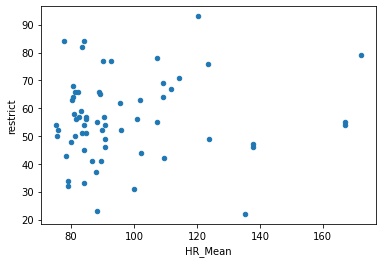

In [11]:
#just in case you want to do some scatterplots 
#you'll notice a lot of outliers in some of these plots - we may want to establish some way to remove outliers - perhaps if something is 4+ SDs from the mean?
ax1= mydf.plot.scatter(x='HR_Mean',y='restrict')

In [12]:
#/Users/sandoval/Library/CloudStorage/Box-Box/R15 Sensor Preprocessing and Analysis/JPCS Special Issue/normalizing.ipynb

#this will save the centered survey windows
surv.to_csv("""C:/Users/Luis/Box/R15 Sensor Preprocessing and Analysis/JPCS Special Issue/Normalized Data/PR128 Survey Windows CENTERED.csv""")

#this will save our correlation matrix 
corr_df.to_csv("""C:/Users/Luis/Box/R15 Sensor Preprocessing and Analysis/JPCS Special Issue/Correlation Matrices/PR128 Survey Correlations.csv""")

#this will save the summary features and EMA
mydf.to_csv("""C:/Users/Luis/Box/R15 Sensor Preprocessing and Analysis/JPCS Special Issue/Summary Physio and EMA/PR128 Survey Window Summary.csv""")

In [13]:
mydf

,Time,HR_Mean,HR_Minimum,HR_Maximum,HR_Stdev,HR_RMS,HR_MAV,HR_Median,HR_P25,HR_P75,...,socialanx_meanCentered,socialanx_medCentered,sens_body_meanCentered,sens_body_medCentered,ridthoughts_meanCentered,ridthoughts_medCentered,memories_meanCentered,memories_medCentered,chewspit_meanCentered,chewspit_medCentered
0,2022-03-25 18:39:00,78.392912,61.08,98.03,9.412707,78.955752,98.03,79.85,70.77,84.75,...,-4.359551,0.0,0.741573,0.0,1.022472,-1.0,-1.314607,0.0,0.0,0.0
1,2022-03-25 14:53:00,123.766039,83.67,200.65,29.368184,127.201271,200.65,116.10,104.53,141.95,...,-4.359551,0.0,-15.258427,-16.0,-12.977528,-15.0,-1.314607,0.0,0.0,0.0
2,2022-03-24 18:27:00,81.366835,59.48,111.25,10.247335,82.009304,111.25,78.70,74.45,87.78,...,-4.359551,0.0,-15.258427,-16.0,-12.977528,-15.0,-1.314607,0.0,0.0,0.0
3,2022-03-23 21:18:00,89.603111,67.65,105.58,11.408228,90.326137,105.58,93.92,80.97,99.05,...,-4.359551,0.0,-15.258427,-16.0,10.022472,8.0,-1.314607,0.0,0.0,0.0
4,2022-03-23 21:14:00,86.490337,71.97,105.58,10.494469,87.124431,105.58,84.92,76.08,95.55,...,-4.359551,0.0,-15.258427,-16.0,10.022472,8.0,-1.314607,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,2022-02-28 14:18:00,101.851703,77.92,187.35,27.662888,105.539974,187.35,89.95,84.03,105.50,...,-4.359551,0.0,0.741573,0.0,-22.977528,-25.0,-0.314607,1.0,0.0,0.0
60,2022-02-25 22:40:00,95.832491,73.85,121.93,12.922097,96.699417,121.93,95.38,84.83,105.08,...,9.640449,14.0,-7.258427,-8.0,26.022472,24.0,4.685393,6.0,0.0,0.0
61,2022-02-25 21:11:00,75.666356,63.68,82.35,4.902798,75.824962,82.35,76.73,73.72,79.17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
62,2022-02-25 18:23:00,83.565743,64.30,123.05,16.279685,85.136075,123.05,78.07,71.42,89.58,...,20.640449,25.0,18.741573,18.0,27.022472,25.0,16.685393,18.0,0.0,0.0
